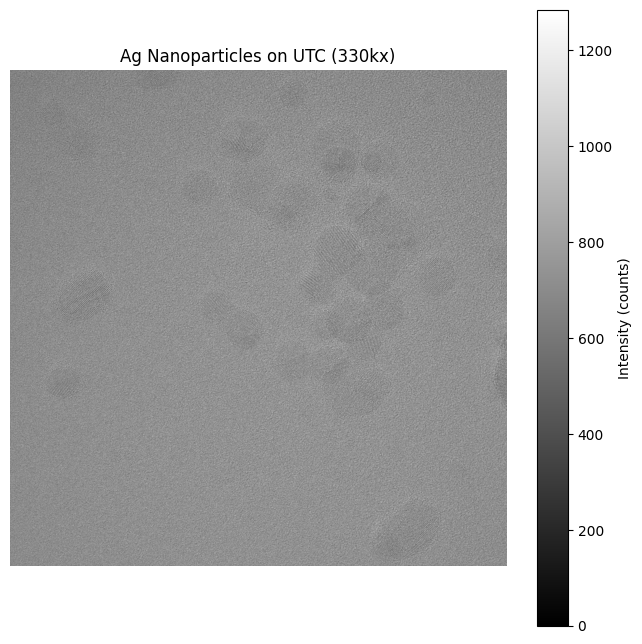

FileNotFoundError: [Errno 2] No such file or directory: 'label_file'

In [43]:
from ncempy.io import dm
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

file = Path("../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/20220202_Ag_UTC_330kx_2650e_0p1596s_02.dm3")
label_file = Path("../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/Labels/20220202_Ag_UTC_330kx_2650e_0p1596s_02_label.png")

# Load the DM3 file
data_dict = dm.dmReader(str(file.resolve()))

image_data = data_dict['data']
plt.figure(figsize=(8, 8))
plt.imshow(image_data, cmap='gray')
plt.title("Ag Nanoparticles on UTC (330kx)")
plt.colorbar(label='Intensity (counts)')
plt.axis('off') 
plt.show()


img = mpimg.imread("label_file")

plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title("PNG Image")
plt.show()

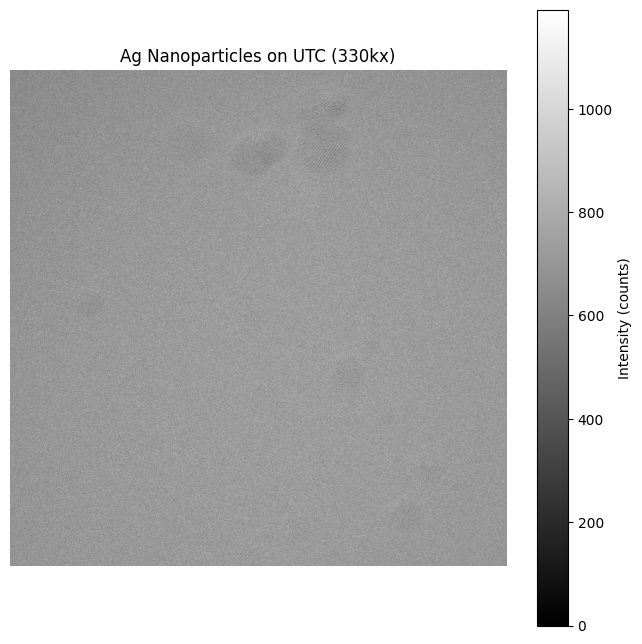

In [38]:
file_2 = Path("../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/20220202_Ag_UTC_330kx_2650e_0p1596s_10.dm3")

# Load the DM3 file
data_dict_2 = dm.dmReader(str(file_2.resolve()))

image_data_2 = data_dict_2['data']

plt.figure(figsize=(8, 8))
plt.imshow(image_data_2, cmap='gray')
plt.title("Ag Nanoparticles on UTC (330kx)")
plt.colorbar(label='Intensity (counts)')
plt.axis('off') 
plt.show()

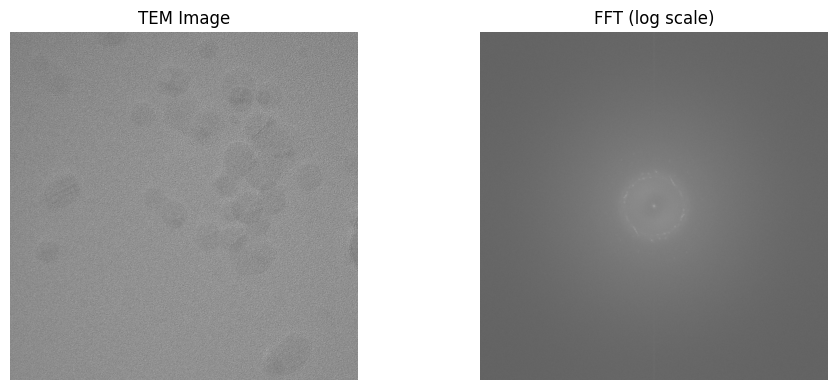

In [2]:
import numpy as np
from numpy.fft import fft2, fftshift

fft_img = fft2(image_data)
fft_img_shifted = fftshift(fft_img)


magnitude = np.abs(fft_img_shifted)
log_magnitude = np.log(1 + magnitude)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("TEM Image")
plt.imshow(image_data, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("FFT (log scale)")
plt.imshow(log_magnitude, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

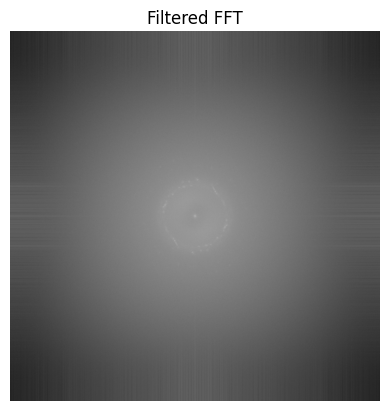

In [3]:
from skimage.filters import gaussian

filtered = gaussian(image_data, sigma=1)
fft_filtered = fftshift(fft2(filtered))
log_filtered = np.log(1 + np.abs(fft_filtered))

plt.imshow(log_filtered, cmap='gray')
plt.title("Filtered FFT")
plt.axis('off')
plt.show()

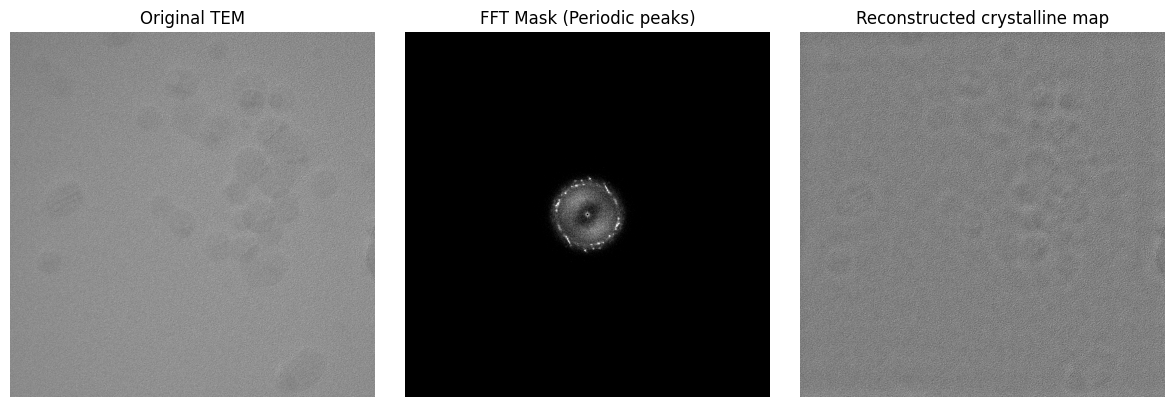

In [7]:
from numpy.fft import fft2, ifft2, fftshift, ifftshift

threshold = np.percentile(magnitude, 99)  
mask = magnitude > threshold

h, w = image_data.shape
cy, cx = h//2, w//2
r = 10
mask[cy-r:cy+r, cx-r:cx+r] = 0

Fshift = fftshift(fft_img)
F_filtered = Fshift * mask

img_filtered = np.real(ifft2(ifftshift(F_filtered)))

img_filtered = (img_filtered - img_filtered.min()) / (img_filtered.max() - img_filtered.min())

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original TEM")
plt.imshow(image_data, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("FFT Mask (Periodic peaks)")
plt.imshow(mask, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Reconstructed crystalline map")
plt.imshow(img_filtered, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

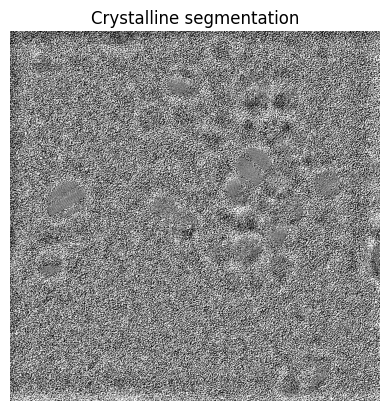

In [17]:
from skimage.filters import threshold_otsu

t = threshold_otsu(img_filtered)
seg = img_filtered > t

plt.imshow(seg, cmap='gray')
plt.title("Crystalline segmentation")
plt.axis('off')
plt.show()

In [24]:
print(seg)

[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]


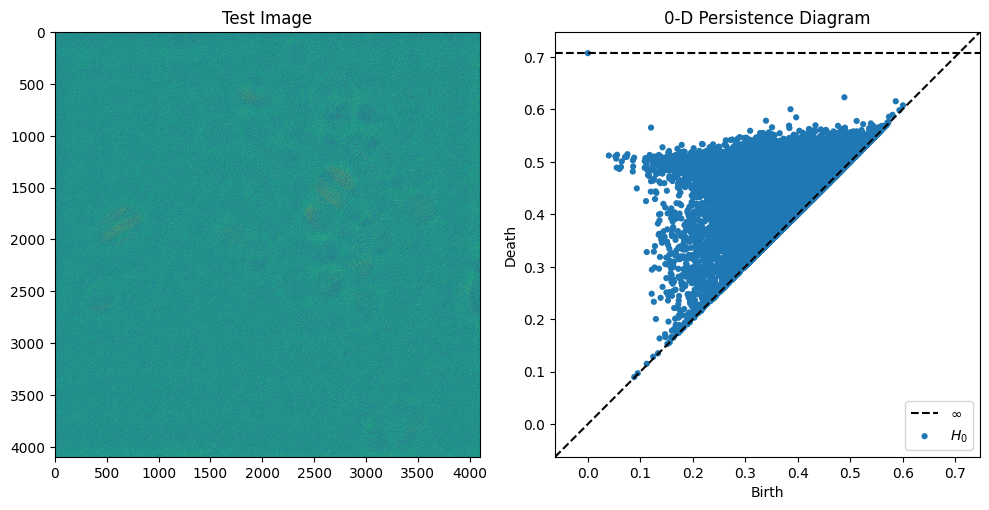

In [26]:
from scipy import ndimage
from persim import plot_diagrams
from ripser import lower_star_img

reverse = 255 - seg
dgm = lower_star_img(img_filtered)

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(img_filtered)
plt.title("Test Image")
plt.subplot(122)
plot_diagrams(dgm)
plt.title("0-D Persistence Diagram")
plt.tight_layout()
plt.show()

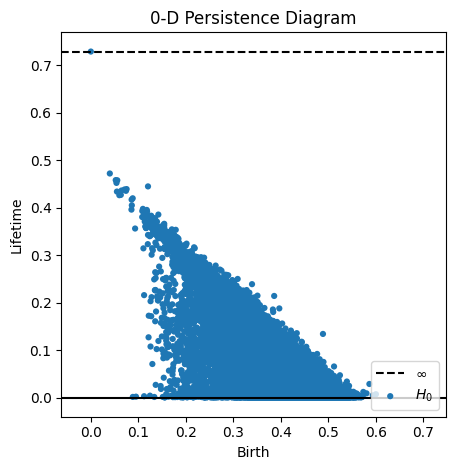

In [37]:
plot_diagrams(dgm, lifetime=True)
plt.title("0-D Persistence Diagram")
plt.tight_layout()
plt.show()

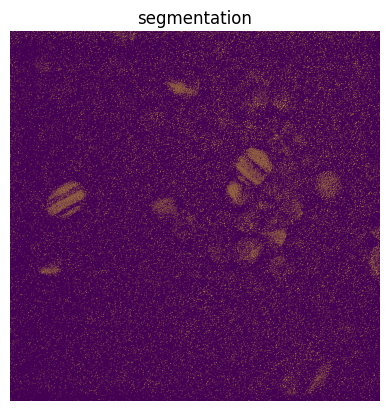

In [30]:
import copy

def segment_by_birth(threshold, image, dgm):

    life = dgm[:,1] - dgm[:,0]

    idxs = np.where((life > threshold) &
                    (dgm[:,1] != np.inf))[0]

    h, w =image.shape

    segmentedpixels = np.zeros((h, w))

    for i in idxs:

        birth = dgm[i, 0]
        death = dgm[i, 1]

        detected_mask = (image <= birth).astype(np.uint8)

        detected_mask *= 255

        # remove overlap
        non_overlapping_mask = copy.deepcopy(detected_mask)
        non_overlapping_mask[segmentedpixels > 0] = 0

        segmentedpixels[non_overlapping_mask > 0] = 255
    return segmentedpixels


seg_ph = segment_by_birth(0.17, img_filtered, dgm)
plt.imshow(seg_ph)
plt.title("segmentation")
plt.axis("off")
plt.show()


In [31]:
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view

def extract_patches_3x3(image):
    H, W = image.shape

    windows = sliding_window_view(image, (9, 9))

    patches = windows.reshape(-1, 9, 9)

    coords = []
    for i in range(H - 2):
        for j in range(W - 2):
            coords.append((i + 1, j + 1))  

    return patches, np.array(coords)

In [32]:
print(image_data.shape)
patches, coords = extract_patches_3x3(image_data)
print(patches.shape) 
print(patches[0])  

(4096, 4096)
(16711744, 9, 9)
[[561.29504 665.03564 626.2838  614.7722  697.2076  655.01654 739.4205
  724.08887 716.82385]
 [512.15106 572.81494 630.88293 646.15216 674.9673  675.76544 694.59393
  699.1884  725.03064]
 [547.7294  510.82172 566.8888  614.17615 659.1602  657.7085  722.4693
  718.7563  786.6    ]
 [541.7095  517.3396  559.51996 614.96    629.7871  636.7567  683.25507
  753.8608  805.8123 ]
 [547.63684 506.21356 573.7428  628.85815 644.296   710.58014 740.50964
  741.4818  782.3784 ]
 [560.5273  586.4496  620.6261  655.76514 678.2018  720.9562  757.7097
  752.73157 757.69745]
 [667.49695 646.7555  667.2023  696.6858  691.29095 707.1209  755.24884
  711.23303 757.69794]
 [703.154   744.3575  717.2751  745.8765  724.5642  769.28674 757.3497
  753.5659  730.8141 ]
 [764.01666 757.1404  715.67065 686.60657 728.2103  744.68445 702.2002
  707.37463 657.9708 ]]


In [41]:
import numpy as np
idx = np.random.choice(len(patches), 10000, replace=False)

patches_subset = patches[idx]
coords_subset = coords[idx]

In [24]:
!pip install umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 17.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 22.2 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [umap-learn]4 [pynndescent]


In [ ]:
import umap.umap_ as umap

patches = patches.reshape(patches.shape[0], -1)

X_3d = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.1).fit_transform(patches)

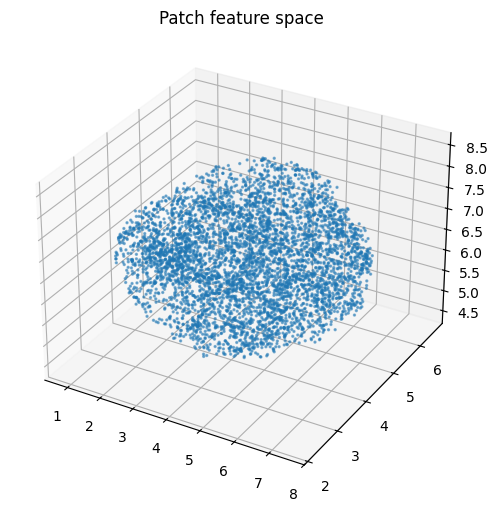

In [35]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_3d[:,0], X_3d[:,1], X_3d[:,2],
           s=2, alpha=0.5)

ax.set_title("Patch feature space")
plt.show()

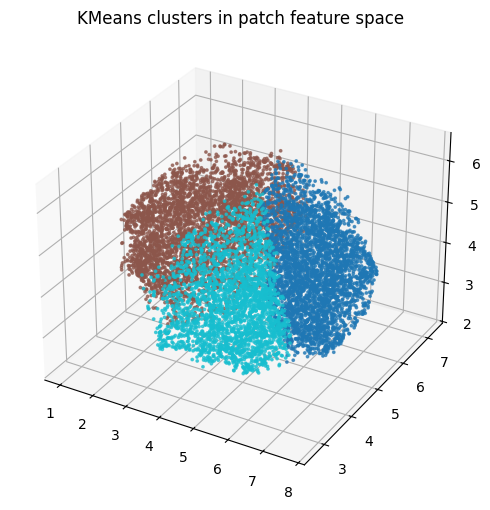

In [43]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

labels = KMeans(n_clusters=3).fit_predict(X_3d)

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_3d[:,0], X_3d[:,1], X_3d[:,2],
    c=labels,
    cmap="tab10",
    s=3,
    alpha=0.7
)

ax.set_title("KMeans clusters in patch feature space")
plt.show()

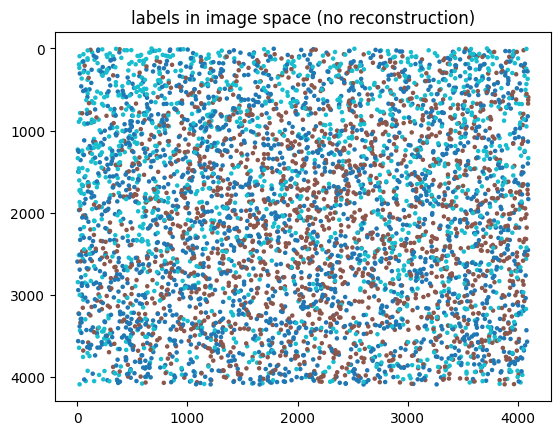

In [29]:
plt.scatter(coords_subset[:,1], coords_subset[:,0], c=labels, s=5, cmap='tab10')
plt.gca().invert_yaxis()
plt.title("labels in image space (no reconstruction)")
plt.show()

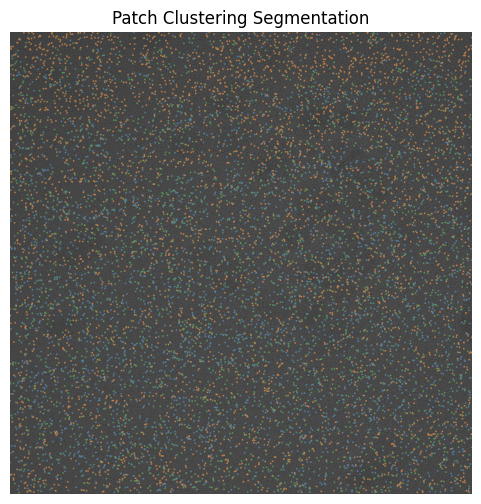

In [ ]:

def visualize_segmentation(image, coords, labels, patch_size=18):

    H, W = image.shape
    seg_img = np.zeros((H, W, 3))

    cmap = plt.get_cmap("tab10")
    half = patch_size // 2

    for (r, c), l in zip(coords, labels):
        color = cmap(l % 10)[:3]

        r0 = max(0, r - half)
        r1 = min(H, r + half + 1)
        c0 = max(0, c - half)
        c1 = min(W, c + half + 1)

        seg_img[r0:r1, c0:c1] = color

    plt.figure(figsize=(6,6))
    plt.imshow(image, cmap="gray")
    plt.imshow(seg_img, alpha=0.8)
    plt.title("Patch Clustering Segmentation")
    plt.axis("off")
    plt.show()

visualize_segmentation(image_data, coords_subset, labels, patch_size=12)


In [ ]:
import numpy as np
idx = np.random.choice(len(patches), 2000, replace=False)

patches_subset = patches[idx]
coords_subset = coords[idx]

In [4]:
import ripser
from persim import plot_diagrams
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
blocks_scaled = scaler.fit_transform(patches)
pca = PCA(n_components=6)
blocks_reduced = pca.fit_transform(blocks_scaled)

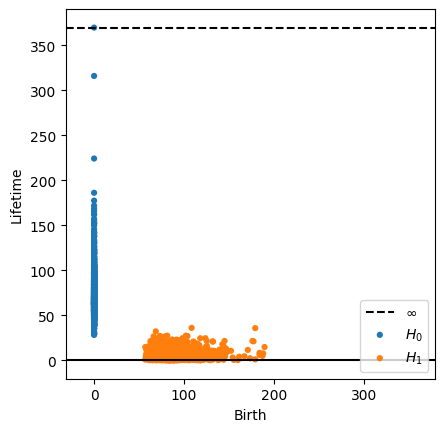

In [16]:
import ripser
from persim import plot_diagrams

X = patches_subset.reshape(patches_subset.shape[0], -1)

r = ripser.ripser(X, maxdim=1, do_cocycles=True)
dgms = r['dgms']
cocycles = r['cocycles'][1] 
plot_diagrams(dgms, show=True, lifetime=True)

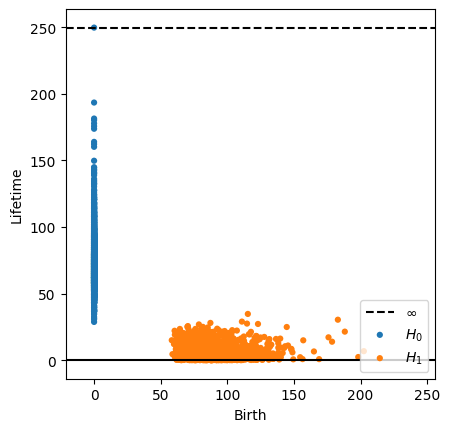

In [35]:
plot_diagrams(dgms, show=True, lifetime=True)

In [ ]:
from sklearn.cluster import DBSCAN

def cluster(X):
    return DBSCAN(eps=0.5, min_samples=10).fit_predict(X)

OverflowError: cannot convert float infinity to integer

Carlsson 3 wheel circle

In [ ]:
import numpy as np
from skimage import io
from itertools import product
from numpy.lib.stride_tricks import sliding_window_view

def extract_patches(image):
    patches = []
    patches = []
    coords = []
    h, w = image.shape
    for i, j in product(range(1,h-1), range(1, w-1)):
        patch = np.log(image[i-1:i+2, j-1:j+2] + 1e-8)
        patch = patch.flatten()
        patch -= patch.mean()
        coords.append((i,j))
        patches.append(patch)
    return np.array(patches), coords

def norm(patch, D):
    return np.sqrt(patch @ D @ patch)

In [7]:
patches, coords = extract_patches(image_data)

e1 = (1/np.sqrt(6)) * np.array([1,0,-1,1,0,-1,1,0,-1])
e2 = (1/np.sqrt(6)) * np.array([1,1,1,0,0,0,-1,-1,-1])
e3 = (1/np.sqrt(54)) * np.array([1,-2,1,1,-2,1,1,-2,1])
e4 = (1/np.sqrt(54)) * np.array([1,1,1,-2,-2,-2,1,1,1])

# Project all patches
a1 = patches @ e1
a2 = patches @ e2
a3 = patches @ e3
a4 = patches @ e4

In [ ]:
from sklearn.neighbors import NearestNeighbors

k=15

nbrs = NearestNeighbors(n_neighbors=k).fit(patches)
distances, _ = nbrs.kneighbors(patches)
density = 1 / distances[:, -1]

threshold = np.percentile(density, 70)
dense_patches = patches[density > threshold]

In [ ]:
!pip install gudhi

In [ ]:
import gudhi

idx = np.random.choice(len(dense_patches), min(2000, len(dense_patches)), replace=False)
sample = dense_patches[idx]

rips = gudhi.RipsComplex(points=sample, max_edge_length=2)
simplex_tree = rips.create_simplex_tree(max_dimension=2)
simplex_tree.compute_